Load up the results of the quality control to save out in Matlab readable files. We want to combine all measures of quality for each point in time. Large vector of good/bad times if binned

In [1]:
qc_outdir       ='/home/huklab/Documents/RyanSorting/SpikeSortingTools/pipeline_results_Gru_20220412_combined/qc'
waveformsfile   ='waveforms/waveforms.npz'
refractoryfile  ='refractory/refractory_qc.npz'
truncation      ='amp_truncation/truncation_qc.npz'

presencefile    ='amp_truncation/present_qc.npz'

#load the files
import numpy as np
import os
from pathlib import Path

def load_qc_data(qc_outdir, filename):
    filepath = Path(qc_outdir) / filename
    if not filepath.exists():
        raise FileNotFoundError(f"File {filepath} does not exist.")
    
    try:
        data = np.load(filepath, allow_pickle=True)
        return data
    except Exception as e:
        raise RuntimeError(f"Failed to load {filepath}: {e}")

# Load the data
waveforms_data = load_qc_data(qc_outdir, waveformsfile)
refractory_data = load_qc_data(qc_outdir, refractoryfile)
truncation_data = load_qc_data(qc_outdir, truncation)
presence_data = load_qc_data(qc_outdir, presencefile)

# Print the keys of the loaded data for verification
print("Waveforms data keys:", waveforms_data.keys())
print("Refractory data keys:", refractory_data.keys())
print("Truncation data keys:", truncation_data.keys())
print("Presence data keys:", presence_data.keys())
# Example of accessing specific data
# Example of accessing specific data
def print_data_info(data, name):
    for key in data.keys():
        print(f"{name} - {key}: shape={data[key].shape}, dtype={data[key].dtype}")
print_data_info(waveforms_data, "Waveforms")
print_data_info(refractory_data, "Refractory")
print_data_info(truncation_data, "Truncation")
print_data_info(presence_data, "Presence")


Waveforms data keys: KeysView(NpzFile '/home/huklab/Documents/RyanSorting/SpikeSortingTools/pipeline_results_Gru_20220412_combined/qc/waveforms/waveforms.npz' with keys: waveforms, samples, times, cids)
Refractory data keys: KeysView(NpzFile '/home/huklab/Documents/RyanSorting/SpikeSortingTools/pipeline_results_Gru_20220412_combined/qc/refractory/refractory_qc.npz' with keys: rvl_tensor, refractory_periods, contamination_test_proportions)
Truncation data keys: KeysView(NpzFile '/home/huklab/Documents/RyanSorting/SpikeSortingTools/pipeline_results_Gru_20220412_combined/qc/amp_truncation/truncation_qc.npz' with keys: cid, window_blocks, popts, mpcts)
Presence data keys: KeysView(NpzFile '/home/huklab/Documents/RyanSorting/SpikeSortingTools/pipeline_results_Gru_20220412_combined/qc/amp_truncation/present_qc.npz' with keys: cid, valid_blocks)
Waveforms - waveforms: shape=(654, 82, 383), dtype=float32
Waveforms - samples: shape=(654, 512), dtype=int64
Waveforms - times: shape=(82,), dtype=f

Valid blocks: [[    28   1028]
 [  1666  12666]
 [ 13692  14692]
 ...
 [  1979 144979]
 [  1599   9599]
 [  9700 222700]]
Maximum valid block time: 443464
Maximum truncation block time: 443463


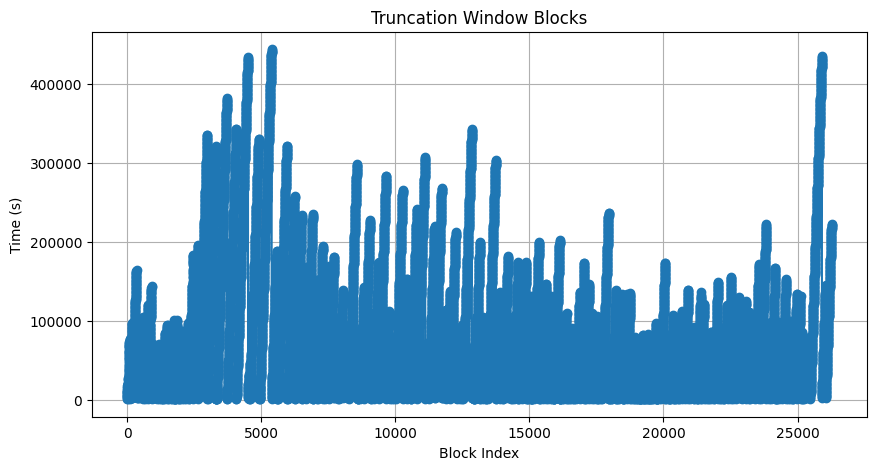

In [2]:
#Check that the time in Presence valid_blocks makes sense
valid_blocks = presence_data['valid_blocks']
if valid_blocks.size > 0:
    if np.any(valid_blocks < 0):
        raise ValueError("Invalid blocks contain negative values, which is unexpected.")
    print("Valid blocks:", valid_blocks)

# maximum value in presence_data['valid_blocks'] second column should be less than or equal to the maximum time in truncation- window_blocks
max_valid_block = np.max(valid_blocks[:, 1])
max_truncation_block = np.max(truncation_data['window_blocks'][:, 1])

# print the maximum values for verification
print("Maximum valid block time:", max_valid_block)
print("Maximum truncation block time:", max_truncation_block)

# Check if the window_blocks are likely to be time in seconds. Plot all vales
import matplotlib.pyplot as plt
def plot_window_blocks(window_blocks, title):
    plt.figure(figsize=(10, 5))
    plt.plot(window_blocks[:, 1], marker='o')
    plt.title(title)
    plt.xlabel('Block Index')
    plt.ylabel('Time (s)')
    plt.grid()
    plt.show()
plot_window_blocks(truncation_data['window_blocks'], "Truncation Window Blocks")



Number of unique cids in truncation data: 408


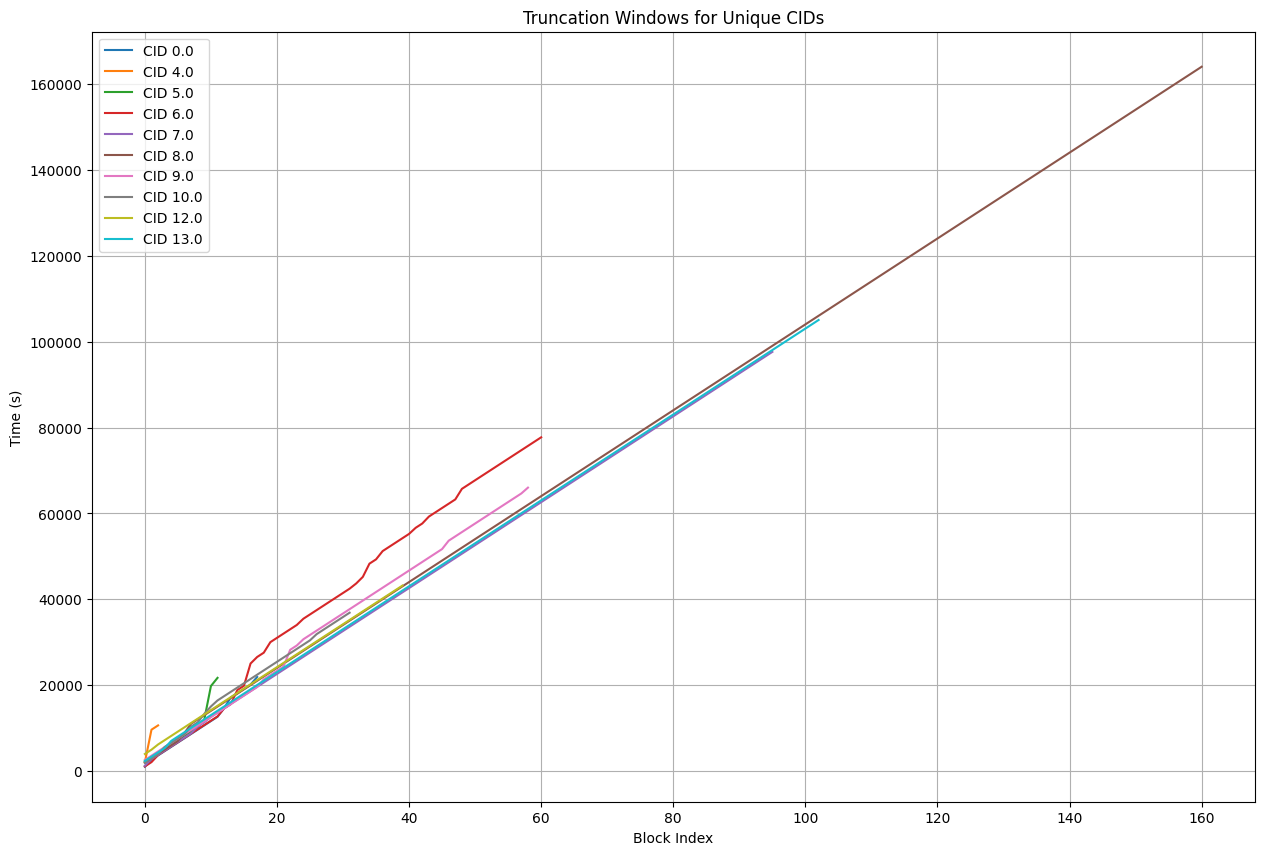

In [3]:
#How many unique truncation - cids are there?
unique_cids = np.unique(truncation_data['cid'])
print("Number of unique cids in truncation data:", len(unique_cids))

# Plot truncation windows for first 10 unique cid
def plot_truncation_windows(truncation_data, unique_cids, num_plots=10):
    plt.figure(figsize=(15, 10))
    for i, cid in enumerate(unique_cids[:num_plots]):
        idx = np.where(truncation_data['cid'] == cid)[0]
        if idx.size > 0:
            plt.plot(truncation_data['window_blocks'][idx, 1], label=f'CID {cid}')
    plt.title('Truncation Windows for Unique CIDs')
    plt.xlabel('Block Index')
    plt.ylabel('Time (s)')
    plt.legend()
    plt.grid()
    plt.show()
plot_truncation_windows(truncation_data, unique_cids)

Its likely that we need to convert back from window_blocks, to time. Difference in truncation window blocks is always 1000?

In [4]:
#Saving out the data to matlab compatible mat files
import scipy.io as sio
def save_to_mat(data, filename):
    """Save numpy data to a .mat file."""
    try:
        sio.savemat(filename, data)
        print(f"Data saved to {filename}")
    except Exception as e:
        raise RuntimeError(f"Failed to save data to {filename}: {e}")
# Define output filenames
output_waveforms_file = os.path.join(qc_outdir, 'waveforms_data.mat')
output_refractory_file = os.path.join(qc_outdir, 'refractory_data.mat')
output_truncation_file = os.path.join(qc_outdir, 'truncation_data.mat')
output_presence_file = os.path.join(qc_outdir, 'presence_data.mat')
# Save the data to .mat files
save_to_mat(waveforms_data, output_waveforms_file)
save_to_mat(refractory_data, output_refractory_file)
save_to_mat(truncation_data, output_truncation_file)
save_to_mat(presence_data, output_presence_file)
# Print confirmation of saved files
print("All data has been saved successfully.")
# Print the directory where the files were saved
print(f"Files saved in: {qc_outdir}")


Data saved to /home/huklab/Documents/RyanSorting/SpikeSortingTools/pipeline_results_Gru_20220412_combined/qc/waveforms_data.mat
Data saved to /home/huklab/Documents/RyanSorting/SpikeSortingTools/pipeline_results_Gru_20220412_combined/qc/refractory_data.mat
Data saved to /home/huklab/Documents/RyanSorting/SpikeSortingTools/pipeline_results_Gru_20220412_combined/qc/truncation_data.mat
Data saved to /home/huklab/Documents/RyanSorting/SpikeSortingTools/pipeline_results_Gru_20220412_combined/qc/presence_data.mat
All data has been saved successfully.
Files saved in: /home/huklab/Documents/RyanSorting/SpikeSortingTools/pipeline_results_Gru_20220412_combined/qc


In [ ]:
# Example of accessing a specific array
def get_specific_array(data, key):
    if key in data:
        return data[key]
    else:
        raise KeyError(f"Key {key} not found in data.")
# Example usage
try:
    waveforms = get_specific_array(waveforms_data, 'waveforms')
    print("Waveforms shape:", waveforms.shape)
except KeyError as e:
    print(e)
try:
    refractory_periods = get_specific_array(refractory_data, 'refractory_periods')
    print("Refractory periods shape:", refractory_periods.shape)
except KeyError as e:       
    print(e)
try:
    truncation_info = get_specific_array(truncation_data, 'truncation_info')
    print("Truncation info shape:", truncation_info.shape)
except KeyError as e:
    print(e)
try:
    presence_info = get_specific_array(presence_data, 'presence_info')
    print("Presence info shape:", presence_info.shape)
except KeyError as e:
    print(e)
# Save the loaded data to a new file for further processing
output_file = Path(qc_outdir) / 'qc_data_summary.npz'
np.savez(output_file, 
         waveforms=waveforms_data['waveforms'], 
         refractory_periods=refractory_data['refractory_periods'], 
         truncation_info=truncation_data['truncation_info'], 
         presence_info=presence_data['presence_info'])
print(f"QC data summary saved to {output_file}")
# End of the script
# Note: Ensure that the directory and file paths are correct and accessible.